# Solutions Notebook: Z-Tests and Power Analysis

Full worked solutions to `02_skeleton_practice.ipynb`, with brief explanations of *why* each step
is done, not just the code. Try the skeleton notebook yourself first — you'll learn more from a
genuine attempt (even a wrong one) than from reading this straight through.


In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import math

from statsmodels.stats.weightstats import ztest
from statsmodels.stats.proportion import proportions_ztest, proportion_effectsize
from statsmodels.stats.power import (
    TTestPower, TTestIndPower, NormalIndPower,
    GofChisquarePower, FTestPower, FTestAnovaPower
)
from statsmodels.stats.gof import chisquare_effectsize

np.random.seed(42)
plt.rcParams['figure.figsize'] = (7, 4)


## Part A — Z-scores refresher and visualization

In [2]:
exam_scores = np.array([58, 65, 71, 74, 77, 80, 62, 90, 69, 85, 73, 55])
mu, sigma = 72, 9

z_scores = (exam_scores - mu) / sigma

exam_df = pd.DataFrame({"score": exam_scores, "z_score": z_scores}).sort_values("score").reset_index(drop=True)
exam_df

,score,z_score
0,55,-1.888889
1,58,-1.555556
2,62,-1.111111
3,65,-0.777778
4,69,-0.333333
5,71,-0.111111
6,73,0.111111
7,74,0.222222
8,77,0.555556
9,80,0.888889


**Why divide by the population σ (9), not `stats.zscore(exam_scores)`?** `stats.zscore` would standardize against *this sample's own* mean/std, which answers a different question ('how does this student compare to the other 11 students in the room?') than the one asked ('how does this student compare to the known, established population of all students who take this exam?').

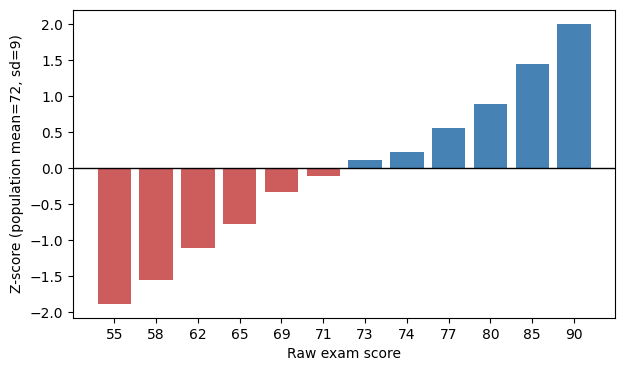

In [3]:
fig, ax = plt.subplots()
ax.bar(range(len(exam_df)), exam_df["z_score"],
       color=np.where(exam_df["z_score"] >= 0, "steelblue", "indianred"))
ax.axhline(0, color="black", linewidth=1)
ax.set_xticks(range(len(exam_df)))
ax.set_xticklabels(exam_df["score"])
ax.set_xlabel("Raw exam score")
ax.set_ylabel("Z-score (population mean=72, sd=9)")
plt.show()

In [4]:
z_low = (65 - mu) / sigma
z_high = (85 - mu) / sigma
prob_between = stats.norm.cdf(z_high) - stats.norm.cdf(z_low)
print(f"z(65)={z_low:.3f}, z(85)={z_high:.3f}, P(65<score<85)={prob_between:.4f}")

z(65)=-0.778, z(85)=1.444, P(65<score<85)=0.7073


In [5]:
n = 6
se = sigma / math.sqrt(n)
z_low_mean = (65 - mu) / se
z_high_mean = (85 - mu) / se
prob_mean_between = stats.norm.cdf(z_high_mean) - stats.norm.cdf(z_low_mean)
print(f"SE={se:.3f}, P(65<mean<85)={prob_mean_between:.4f}")

SE=3.674, P(65<mean<85)=0.9714


**Why is the sample-mean probability so much higher?** The standard error (σ/√n ≈ 3.67) is much smaller than σ itself (9). A tighter spread means more of the distribution's probability mass falls inside any fixed interval like (65, 85) — sample means are less variable than individual observations, which is exactly what the Central Limit Theorem predicts.

## Part B — One-sample Z-test for a mean

In [6]:
mu0 = 4.5
sigma_wait = 1.2
n_wait = 40
xbar_wait = 4.9
alpha = 0.05

z_stat = (xbar_wait - mu0) / (sigma_wait / math.sqrt(n_wait))
p_value = stats.norm.sf(z_stat)
print(z_stat, p_value)

2.1081851067789215 0.017507490509831167


In [7]:
crit_right = stats.norm.ppf(1 - alpha)
print("critical value:", crit_right)
print("REJECT H0" if z_stat > crit_right else "Fail to reject H0")

critical value: 1.6448536269514722
REJECT H0


**Why right-tailed?** Ha says wait times have *increased*, i.e., the true mean is *greater than* 4.5 — that's a one-directional claim, so all of alpha goes in the right tail rather than being split across both tails.

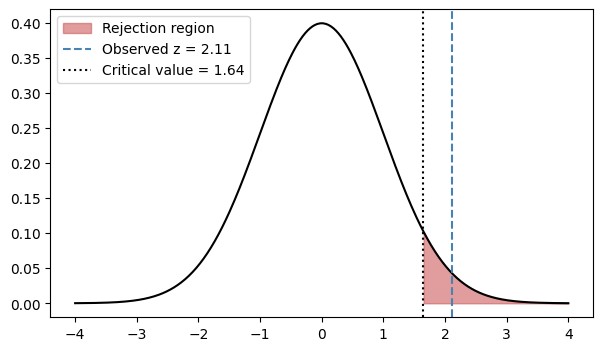

In [8]:
fig, ax = plt.subplots()
x = np.linspace(-4, 4, 400)
y = stats.norm.pdf(x)
ax.plot(x, y, color="black")
reject_region = x >= crit_right
ax.fill_between(x[reject_region], y[reject_region], color="indianred", alpha=0.6, label="Rejection region")
ax.axvline(z_stat, color="steelblue", linestyle="--", label=f"Observed z = {z_stat:.2f}")
ax.axvline(crit_right, color="black", linestyle=":", label=f"Critical value = {crit_right:.2f}")
ax.legend()
plt.show()

In [9]:
simulated_waits = np.random.normal(loc=xbar_wait, scale=sigma_wait, size=n_wait)
z_stat_sm, p_value_sm = ztest(simulated_waits, value=mu0, alternative='larger')
print(z_stat_sm, p_value_sm)

0.7613323776370611 0.22322928319308172


## Part C — Two-sample Z-test for two means

In [10]:
factory_X = [412, 405, 398, 420, 415, 402, 411, 408, 419, 400,
             414, 407, 403, 417, 410, 406, 413, 409, 401, 416,
             404, 418, 399, 412, 411, 405, 408, 414, 402, 410]
factory_Y = [395, 388, 401, 392, 390, 397, 394, 385, 399, 391,
             396, 389, 393, 400, 387, 398, 392, 386, 395, 390,
             393, 391, 397, 388, 394, 399, 386, 392, 400, 389]

z_stat_xy, p_value_xy = ztest(factory_X, factory_Y, value=0, alternative='two-sided')
print(z_stat_xy, p_value_xy)
print("REJECT H0" if p_value_xy <= 0.05 else "Fail to reject H0")

11.37502208035642 5.5688762714087996e-30
REJECT H0


In [11]:
def pooled_standard_deviation(sample1, sample2):
    n1, n2 = len(sample1), len(sample2)
    s1, s2 = np.std(sample1, ddof=1), np.std(sample2, ddof=1)
    return math.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2))

pooled_sd = pooled_standard_deviation(factory_X, factory_Y)
cohens_d = abs(np.mean(factory_X) - np.mean(factory_Y)) / pooled_sd
print(pooled_sd, cohens_d, "-> large effect (d > 0.8)")

5.470401023354854 2.9370180719974703 -> large effect (d > 0.8)


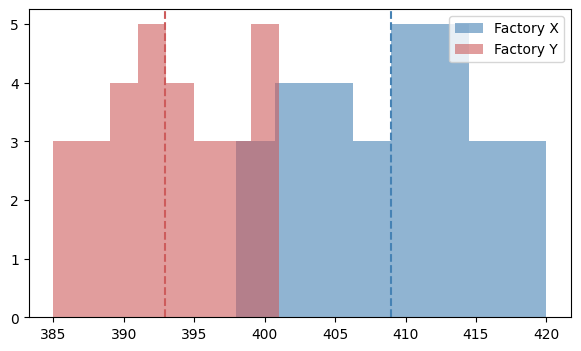

In [12]:
fig, ax = plt.subplots()
ax.hist(factory_X, bins=8, alpha=0.6, label="Factory X", color="steelblue")
ax.hist(factory_Y, bins=8, alpha=0.6, label="Factory Y", color="indianred")
ax.axvline(np.mean(factory_X), color="steelblue", linestyle="--")
ax.axvline(np.mean(factory_Y), color="indianred", linestyle="--")
ax.legend()
plt.show()

## Part D — Z-tests for one and two proportions

In [13]:
count_conversions = 110
nobs_trials = 800
p0 = 0.12

z_stat_p, p_value_p = proportions_ztest(count_conversions, nobs_trials, p0, alternative='two-sided')
observed_p = count_conversions / nobs_trials
print(observed_p, z_stat_p, p_value_p)
print("REJECT H0" if p_value_p <= 0.05 else "Fail to reject H0")

0.1375 1.4373156065501682 0.1506283363278657
Fail to reject H0


In [14]:
p1_bar = 92 / 620
p2_bar = 78 / 590
n1, n2 = 620, 590

p_pool = (p1_bar * n1 + p2_bar * n2) / (n1 + n2)
z_stat_2p = (p1_bar - p2_bar) / math.sqrt(p_pool * (1 - p_pool) * (1/n1 + 1/n2))
p_value_2p = stats.norm.sf(abs(z_stat_2p)) * 2
print(p_pool, z_stat_2p, p_value_2p)
print("REJECT H0" if p_value_2p <= 0.05 else "Fail to reject H0 -- no evidence platforms differ")

0.14049586776859505 0.8097508470328323 0.41808338781904497
Fail to reject H0 -- no evidence platforms differ


In [15]:
z_check, p_check = proportions_ztest([92, 78], [620, 590], alternative='two-sided')
print(z_check, p_check, "-- matches the manual calculation above")

0.8097508470328323 0.41808338781904497 -- matches the manual calculation above


## Part E — Confidence intervals

In [16]:
def z_confidence_interval_mean(xbar, sigma, n, confidence=0.95):
    alpha = 1 - confidence
    z_crit = stats.norm.ppf(1 - alpha/2)
    margin = z_crit * (sigma / math.sqrt(n))
    return xbar - margin, xbar + margin

def z_confidence_interval_proportion(p_hat, n, confidence=0.95):
    alpha = 1 - confidence
    z_crit = stats.norm.ppf(1 - alpha/2)
    margin = z_crit * math.sqrt(p_hat * (1 - p_hat) / n)
    return p_hat - margin, p_hat + margin

ci_wait = z_confidence_interval_mean(xbar_wait, sigma_wait, n_wait)
ci_conversion = z_confidence_interval_proportion(observed_p, nobs_trials)
print(ci_wait, ci_conversion)

(np.float64(4.528122980617264), np.float64(5.271877019382737)) (np.float64(0.11363650782532307), np.float64(0.16136349217467694))


**Link to Part D:** 0.12 falls *outside* the 95% CI for the conversion rate, which is exactly consistent with rejecting H0: p = 0.12 at alpha = 0.05 in Part D — a two-sided test's rejection region and its complementary confidence interval always agree.

## Part F — Power analysis

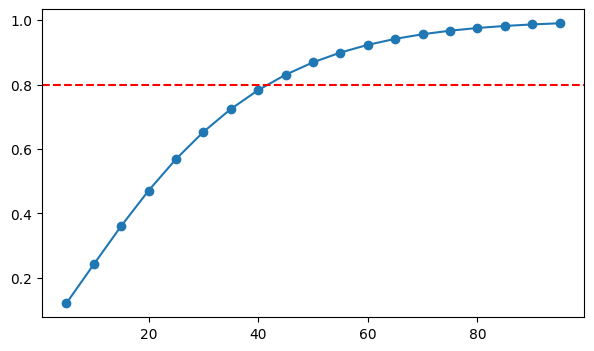

0.4444444444444444 42


In [17]:
effect_size_t = abs(520 - 500) / 45
alpha = 0.05

powers_t = TTestPower()
sample_sizes = np.arange(5, 100, 5)
power_values = [powers_t.solve_power(effect_size_t, nobs=n, alpha=alpha, alternative='two-sided')
                for n in sample_sizes]

fig, ax = plt.subplots()
ax.plot(sample_sizes, power_values, marker='o')
ax.axhline(0.8, color='red', linestyle='--')
plt.show()

required_n = powers_t.solve_power(effect_size_t, power=0.8, alpha=alpha, alternative='two-sided')
print(effect_size_t, math.ceil(required_n))

In [18]:
powers_z = NormalIndPower()
achieved_power = powers_z.solve_power(cohens_d, nobs1=30, ratio=1.0, alpha=0.05, alternative='two-sided')
required_n_z = powers_z.solve_power(cohens_d, power=0.9, ratio=1.0, alpha=0.05, alternative='two-sided')
print(achieved_power, math.ceil(required_n_z))

1.0 3


In [19]:
effect_size_chi = chisquare_effectsize(probs0=[1/3, 1/3, 1/3], probs1=[0.25, 0.45, 0.30], cohen=True)
power_chi = GofChisquarePower()
achieved_power_chi = power_chi.solve_power(effect_size_chi, nobs=150, alpha=0.05, n_bins=3)
required_n_chi = power_chi.solve_power(effect_size_chi, power=0.8, alpha=0.05, n_bins=3)
print(effect_size_chi, achieved_power_chi, math.ceil(required_n_chi))

0.25495097567963926 0.8049793438478253 149


In [20]:
route_stats = pd.DataFrame({
    "route": ["A", "B", "C"],
    "mean": [38, 41, 36],
    "std": [5.0, 5.5, 4.8],
    "n": [40, 35, 45],
})

def pooled_sd_multi(df):
    numerator = sum((row['n'] - 1) * row['std']**2 for _, row in df.iterrows())
    denominator = sum(row['n'] - 1 for _, row in df.iterrows())
    return math.sqrt(numerator / denominator)

pooled_sd_routes = pooled_sd_multi(route_stats)
effect_size_anova = (route_stats['mean'].max() - route_stats['mean'].min()) / pooled_sd_routes

power_anova = FTestAnovaPower()
required_n_anova = power_anova.solve_power(effect_size=effect_size_anova, nobs=None,
                                            alpha=0.05, power=0.8, k_groups=3)
print(pooled_sd_routes, effect_size_anova, math.ceil(required_n_anova))

5.078242511789586 0.9845926003714988 14


## Part G — Monte Carlo power analysis

In [21]:
def monte_carlo_power_two_sample_t(n_per_group, true_diff, distribution='normal',
                                    alpha=0.05, n_simulations=2000, seed=0):
    rng = np.random.default_rng(seed)
    rejections = 0
    for _ in range(n_simulations):
        if distribution == 'normal':
            group1 = rng.normal(loc=0, scale=1, size=n_per_group)
            group2 = rng.normal(loc=true_diff, scale=1, size=n_per_group)
        elif distribution == 'exponential':
            group1 = rng.exponential(scale=1, size=n_per_group)
            group2 = rng.exponential(scale=1, size=n_per_group) + true_diff
        else:
            raise ValueError("distribution must be 'normal' or 'exponential'")
        t_stat, p_val = stats.ttest_ind(group1, group2)
        if p_val <= alpha:
            rejections += 1
    return rejections / n_simulations

power_normal = monte_carlo_power_two_sample_t(30, 0.6, 'normal')
power_skewed = monte_carlo_power_two_sample_t(30, 0.6, 'exponential')
print(power_normal, power_skewed)
print("closed-form:", TTestIndPower().solve_power(effect_size=0.6, nobs1=30, ratio=1.0, alpha=0.05))

0.6165 0.649
closed-form: 0.6275045869747301


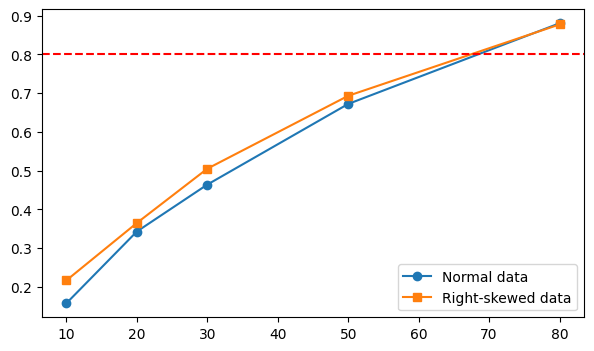

In [22]:
sample_sizes_mc = [10, 20, 30, 50, 80]
powers_normal_curve = [monte_carlo_power_two_sample_t(n, 0.5, 'normal', n_simulations=1000) for n in sample_sizes_mc]
powers_skewed_curve = [monte_carlo_power_two_sample_t(n, 0.5, 'exponential', n_simulations=1000) for n in sample_sizes_mc]

fig, ax = plt.subplots()
ax.plot(sample_sizes_mc, powers_normal_curve, marker='o', label='Normal data')
ax.plot(sample_sizes_mc, powers_skewed_curve, marker='s', label='Right-skewed data')
ax.axhline(0.8, color='red', linestyle='--')
ax.legend()
plt.show()

## Part H — Capstone: plan, simulate, test, and report

In [23]:
p_baseline = 0.08
p_target = 0.10
alpha = 0.05
desired_power = 0.8

effect_size_ab = proportion_effectsize(p_target, p_baseline)
required_n_ab = math.ceil(NormalIndPower().solve_power(
    effect_size_ab, power=desired_power, ratio=1.0, alpha=alpha, alternative='two-sided'))
print(effect_size_ab, required_n_ab)

0.0699880043701876 3205


In [24]:
rng = np.random.default_rng(7)
n_control = required_n_ab
n_treatment = required_n_ab

conversions_control = rng.binomial(n=1, p=p_baseline, size=n_control).sum()
conversions_treatment = rng.binomial(n=1, p=p_target, size=n_treatment).sum()
print(conversions_control, conversions_treatment)

248 321


In [25]:
z_stat_ab, p_value_ab = proportions_ztest(
    [conversions_treatment, conversions_control], [n_treatment, n_control], alternative='two-sided')
print(z_stat_ab, p_value_ab)
decision = "REJECT H0" if p_value_ab <= alpha else "Fail to reject H0"
print(decision)

3.2059159969597624 0.001346332854358992
REJECT H0


In [26]:
p_hat_control = conversions_control / n_control
p_hat_treatment = conversions_treatment / n_treatment
observed_lift = p_hat_treatment - p_hat_control

p_pool_ab = (conversions_control + conversions_treatment) / (n_control + n_treatment)
se_diff = math.sqrt(p_pool_ab * (1 - p_pool_ab) * (1/n_control + 1/n_treatment))
z_crit_95 = stats.norm.ppf(0.975)
ci_low = observed_lift - z_crit_95 * se_diff
ci_high = observed_lift + z_crit_95 * se_diff

print("=== A/B Test Report ===")
print(f"Control rate: {p_hat_control:.4f}, Treatment rate: {p_hat_treatment:.4f}")
print(f"Observed lift: {observed_lift:.4f} (95% CI: [{ci_low:.4f}, {ci_high:.4f}])")
print(f"z = {z_stat_ab:.4f}, p-value = {p_value_ab:.6f}")
print(f"Decision: {decision}")
print("Scope of inference: applies only to visitors matching this sample's population/time window.")

=== A/B Test Report ===
Control rate: 0.0774, Treatment rate: 0.1002
Observed lift: 0.0228 (95% CI: [0.0089, 0.0367])
z = 3.2059, p-value = 0.001346
Decision: REJECT H0
Scope of inference: applies only to visitors matching this sample's population/time window.


## Summary

If your answers matched (up to expected simulation noise where random numbers are involved), you
now have hands-on fluency with every method in the source notebooks plus the extensions. If any
section didn't match, re-read the corresponding part of `00_theory_background.md` — most
mismatches trace back to a mixed-up formula for standard error, a one-tailed vs. two-tailed mix-up,
or forgetting to pool a variance/proportion where the formula calls for it.